In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="talk")

plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS",   # macOS 常见，兼容性好
    "PingFang SC",        # macOS
    "Heiti SC",           # macOS
    "SimHei",             # Windows
    "Microsoft YaHei",    # Windows
    "Noto Sans CJK SC",   # Linux
    "WenQuanYi Micro Hei" # Linux
]
plt.rcParams["axes.unicode_minus"] = False  # 防止负号显示成方块

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

BASE_DIR = Path.cwd()
if BASE_DIR.name != "src":
    BASE_DIR = BASE_DIR / "src"

PCC_PATH = BASE_DIR / "result" / "pcc.csv"
FIG_DIR = BASE_DIR / "result" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pcc_df = pd.read_csv(PCC_PATH)
METHOD_ORDER = ["BP", "RK", "ABRA", "SILVAN", "GPU_SIR_BRIDGE"]
DISPLAY_METHOD_ORDER = ["BP", "RK", "ABRA", "SILVAN", "FastBC"]
BAR_COLORS = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"]

pcc_df.head()


,graph_name,graph_source,num_nodes,num_edges,epsilon,top_k,top_k_ratio,exact_time,BP,RK,ABRA,SILVAN,GPU_SIR_BRIDGE
0,Celegans,real,297,2148,0.2,30,0.1,0.187953,0.964611,0.945642,0.992779,0.997923,0.991834
1,Fb-tvshow,real,3892,17262,0.2,390,0.1,199.501414,0.906577,0.804575,0.918738,0.974043,0.875451
2,Router,real,5022,6258,0.2,503,0.1,163.628969,0.982436,0.964579,0.990666,0.996741,0.702300
3,Soc-hamsterster,real,2000,16097,0.2,200,0.1,10.774516,0.877954,0.841990,0.923592,0.965009,0.968679
4,Yeast,real,2375,11693,0.2,238,0.1,12.728102,0.895332,0.842027,0.957826,0.976414,0.905563


In [2]:
EPSILON = 0.2

GRAPH_GROUPS = {
    "Real": ["bitcoin-alpha", "wiki-Vote",  "p2p-Gnutella06", "Soc-hamsterster"],
    "BA": ["BA1000", "BA2000", "BA3000", "BA5000"],
    "WS": ["WS1000", "WS2000", "WS3000", "WS5000"],
    "ER": ["ER1000", "ER2000", "ER3000", "ER5000"],
}

GRAPH_SOURCE = {
    "Real": "real",
    "BA": "synthetic",
    "WS": "synthetic",
    "ER": "synthetic",
}

available_real = sorted(pcc_df.loc[pcc_df["graph_source"] == "real", "graph_name"].unique())
available_synthetic = sorted(pcc_df.loc[pcc_df["graph_source"] == "synthetic", "graph_name"].unique())

print("Available real graphs:")
print(available_real)
print()
print("Available synthetic graphs:")
print(available_synthetic)


Available real graphs:
['Celegans', 'Fb-tvshow', 'Router', 'Soc-hamsterster', 'Yeast', 'bitcoin-alpha', 'ca-GrQc', 'cora', 'p2p-Gnutella06', 'wiki-Vote']

Available synthetic graphs:
['BA1000', 'BA10000', 'BA2000', 'BA3000', 'BA5000', 'ER1000', 'ER2000', 'ER3000', 'ER5000', 'WS1000', 'WS2000', 'WS3000', 'WS5000']


Saved figure to: /Users/zhangjuyuan/Documents/projects/FastBC/src/result/figures/pcc_bar_grid_4x4.png


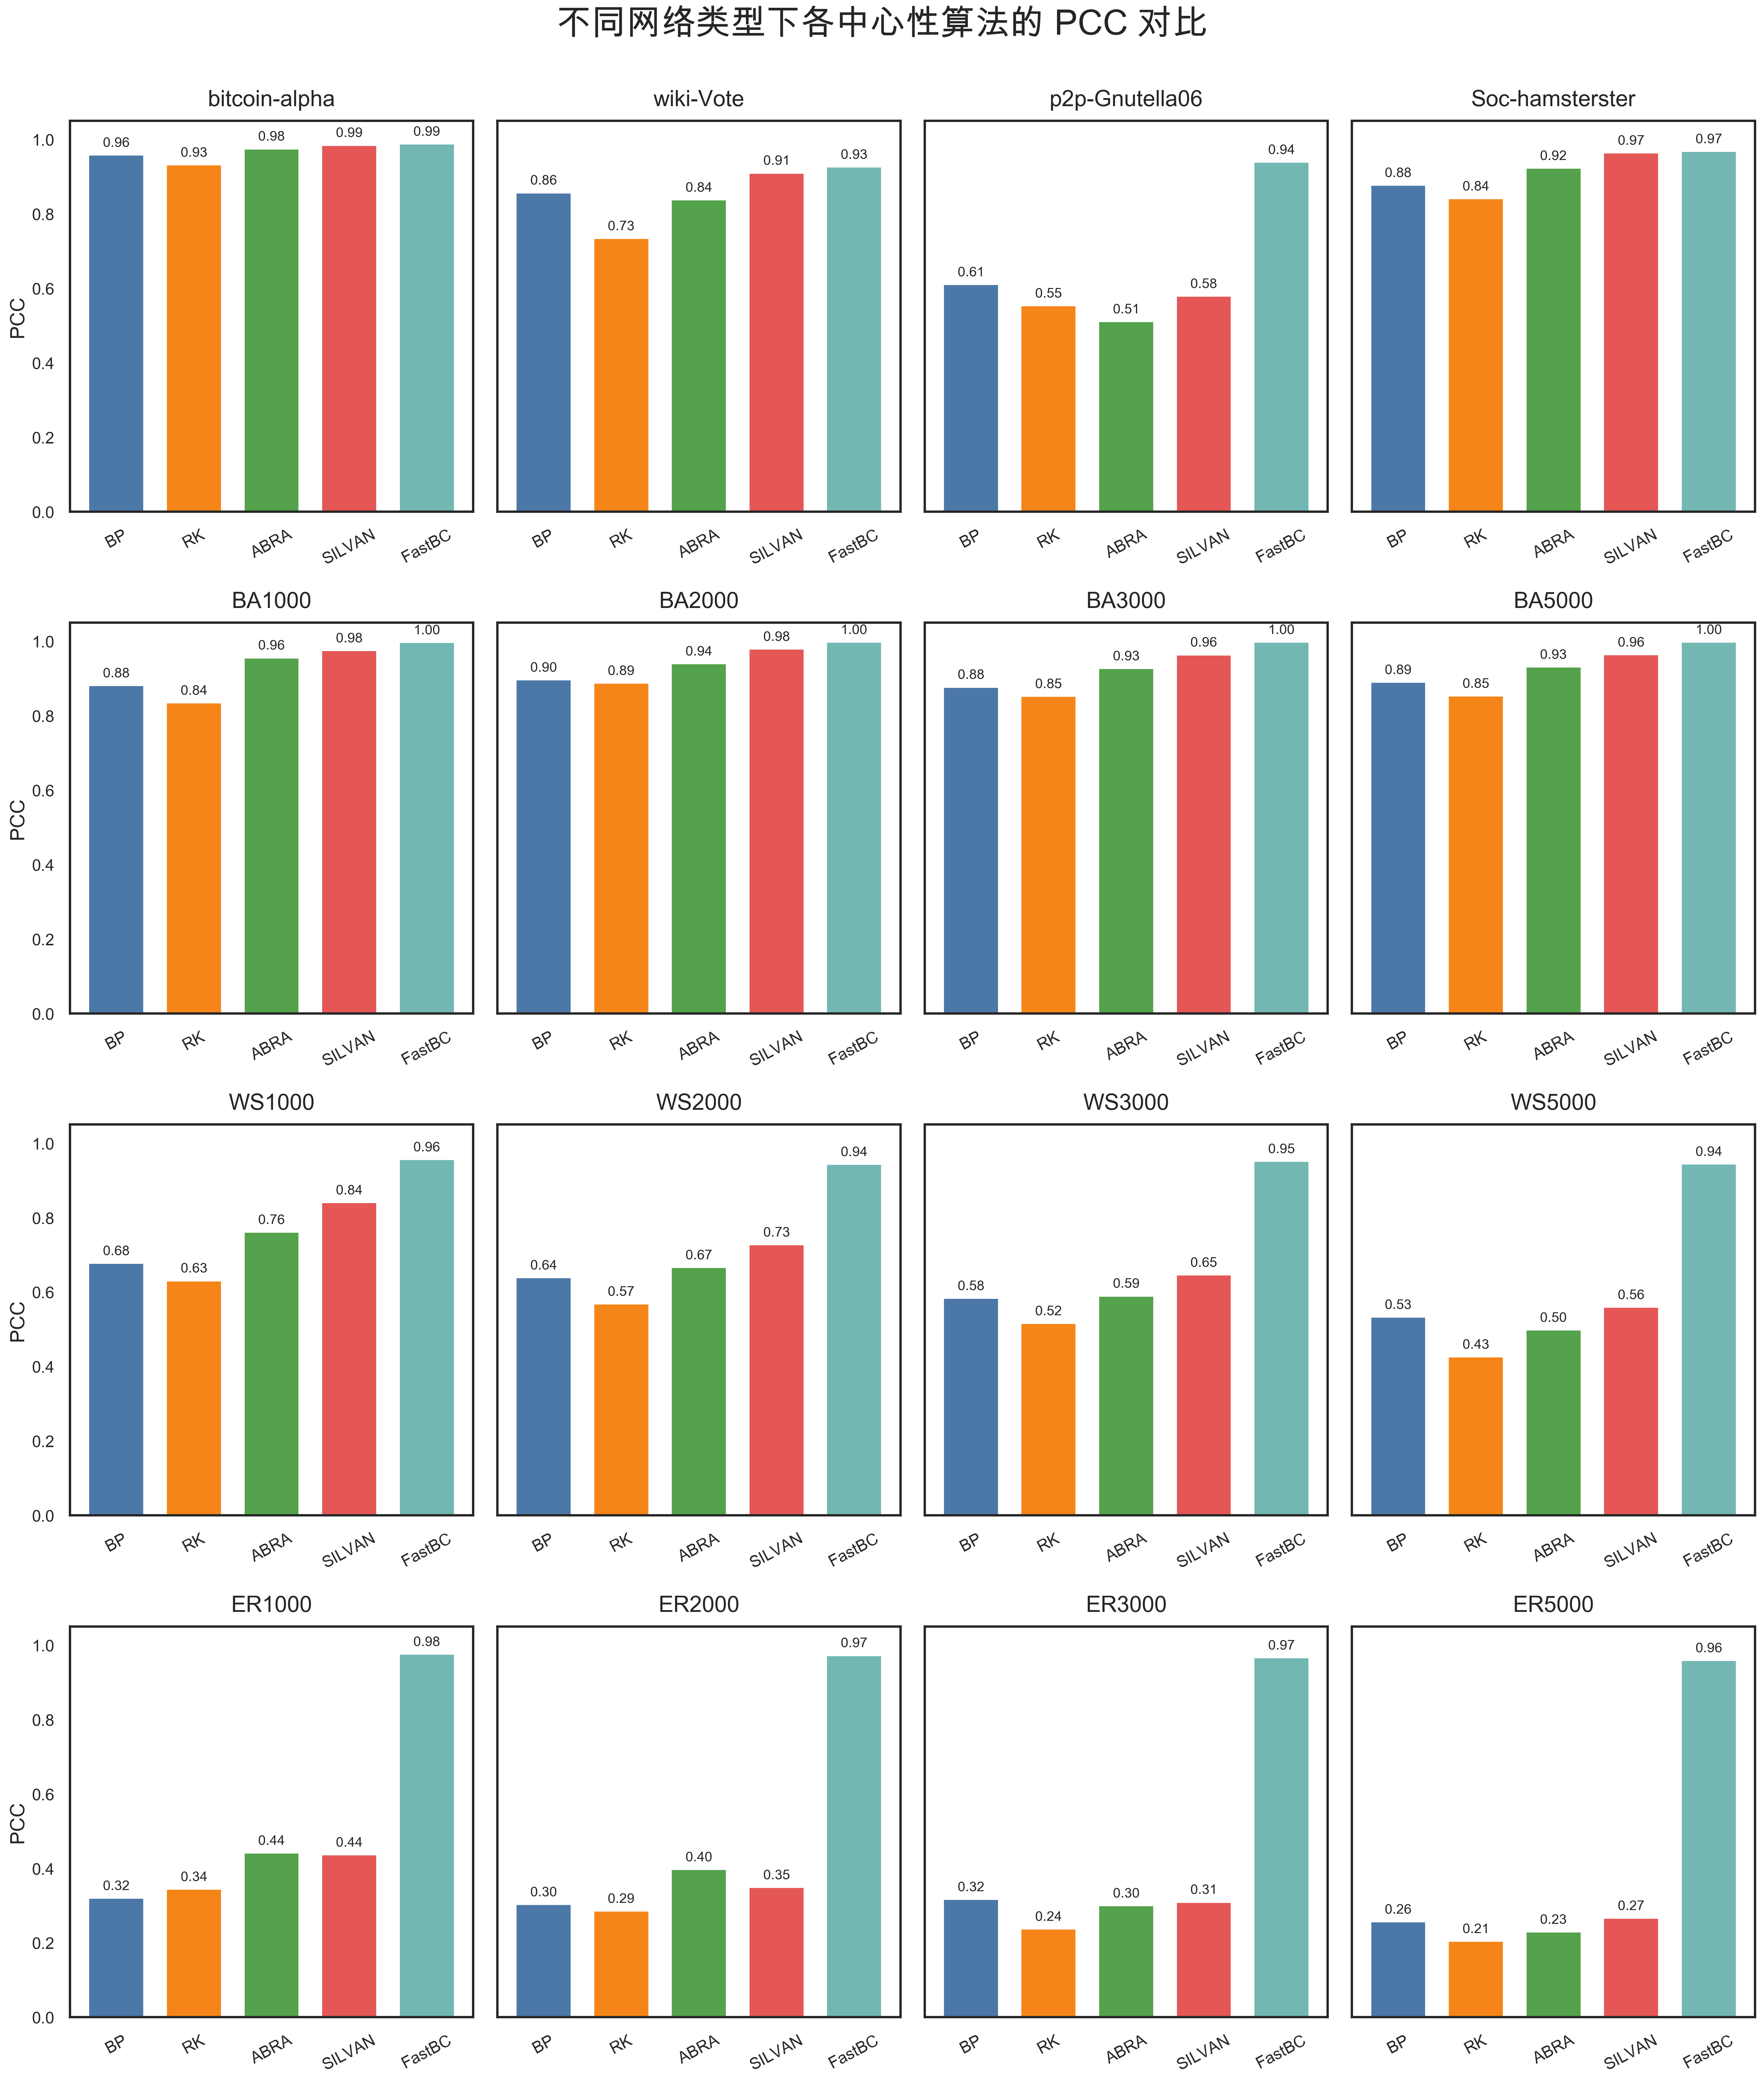

In [3]:
plot_df = pcc_df.loc[pcc_df["epsilon"] == EPSILON].copy()

fig, axes = plt.subplots(4, 4, figsize=(20, 24), sharey=True)
fig.suptitle("不同网络类型下各中心性算法的 PCC 对比", fontsize=28, fontweight="bold", y=0.97)

for row_idx, (group_name, graph_names) in enumerate(GRAPH_GROUPS.items()):
    expected_source = GRAPH_SOURCE[group_name]
    for col_idx, graph_name in enumerate(graph_names):
        ax = axes[row_idx, col_idx]
        row = plot_df.loc[
            (plot_df["graph_source"] == expected_source)
            & (plot_df["graph_name"] == graph_name)
        ]

        if row.empty:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f"Missing\n{graph_name}", ha="center", va="center", fontsize=16, fontweight="bold")
            continue

        values = row.iloc[0][METHOD_ORDER].astype(float)
        bars = ax.bar(DISPLAY_METHOD_ORDER, values, color=BAR_COLORS, width=0.72)
        ax.set_title(graph_name, fontsize=18, fontweight="bold", pad=12)
        ax.set_ylim(0.0, 1.05)
        ax.tick_params(axis="x", rotation=28, labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
        ax.grid(False)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

        if col_idx == 0:
            ax.set_ylabel("PCC", fontsize=16, fontweight="bold")

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                min(value + 0.015, 1.02),
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                rotation=0,
            )

plt.tight_layout(rect=[0, 0, 1, 0.97])
save_path = FIG_DIR / "pcc_bar_grid_4x4.png"
fig.savefig(save_path, bbox_inches="tight")
print(f"Saved figure to: {save_path}")
plt.show()
